# 06 - Model Evaluation and Interpretation

## Objective

The goal of this notebook is to evaluate the strongest churn prediction models in greater detail and translate their predictions into meaningful business insights.

The analysis will focus on:

- Comparing the final candidate models
- Understanding probability thresholds
- Evaluating false positives and false negatives
- Identifying important churn drivers
- Interpreting model predictions
- Creating customer churn-risk segments
- Translating model results into retention recommendations

The final model will not be selected based only on accuracy.

In [58]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.metrics import (
    roc_curve,
    roc_auc_score,
    confusion_matrix,
    accuracy_score,
    precision_score,
    recall_score,
    f1_score
)

import joblib
from pathlib import Path
import sys
import json
import sklearn
from IPython.display import display, Markdown
from sklearn.preprocessing import FunctionTransformer

ROOT = Path.cwd() if (Path.cwd() / 'data').exists() else Path.cwd().parent
sys.path.insert(0, str(ROOT))
from src.churn import RAW_FEATURES, add_features, risk_categories

In [59]:
df = pd.read_csv(ROOT / "data/processed/telco_churn_engineered.csv")

In [60]:
X = df.drop(
    columns=[
        "customerID",
        "Churn",
        "ChurnFlag"
    ]
)

y = df["ChurnFlag"]

In [61]:
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.20,
    random_state=42,
    stratify=y
)

In [62]:
gb_model = joblib.load(ROOT / 'models/tuned_gradient_boosting.joblib')
log_model = joblib.load(ROOT / 'models/balanced_logistic_regression.joblib')

In [63]:
gb_prob = gb_model.predict_proba(X_test)[:, 1]
log_prob = log_model.predict_proba(X_test)[:, 1]

print("Gradient Boosting ROC-AUC:",
      roc_auc_score(y_test, gb_prob))

print("Balanced Logistic ROC-AUC:",
      roc_auc_score(y_test, log_prob))

Gradient Boosting ROC-AUC: 0.8472112428634168
Balanced Logistic ROC-AUC: 0.8421710713270816


## ROC Curve Comparison

ROC curves compare how well the final candidate models distinguish churners from non-churners across different classification thresholds.

A higher ROC-AUC indicates better overall ranking ability.

The ROC curve helps compare models independently of a single fixed classification threshold.

In [64]:
# ROC metrics are imported in the setup cell.

In [65]:
gb_fpr, gb_tpr, _ = roc_curve(y_test, gb_prob)
log_fpr, log_tpr, _ = roc_curve(y_test, log_prob)

gb_auc = roc_auc_score(y_test, gb_prob)
log_auc = roc_auc_score(y_test, log_prob)

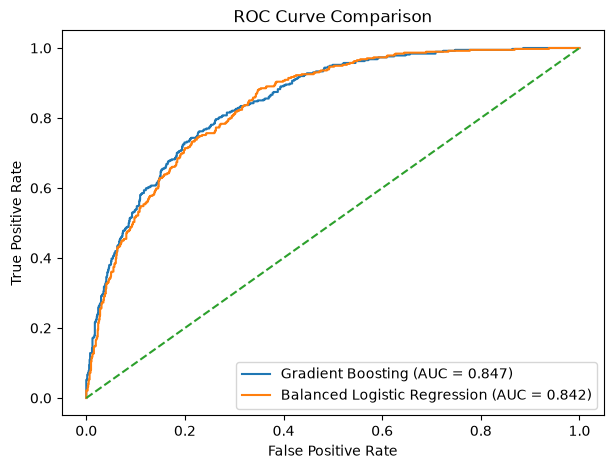

In [66]:
plt.figure(figsize=(7, 5))

plt.plot(
    gb_fpr,
    gb_tpr,
    label=f"Gradient Boosting (AUC = {gb_auc:.3f})"
)

plt.plot(
    log_fpr,
    log_tpr,
    label=f"Balanced Logistic Regression (AUC = {log_auc:.3f})"
)

plt.plot(
    [0, 1],
    [0, 1],
    linestyle="--"
)

plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curve Comparison")
plt.legend()

plt.show()

### ROC Curve Insight

Both final models show similar discrimination ability.

Tuned Gradient Boosting achieves a slightly higher ROC-AUC than Balanced Logistic Regression.

However, ROC-AUC alone does not determine which model is more suitable for customer retention. The classification threshold must also be considered because it directly affects how many churners are identified and how many non-churners are incorrectly flagged.

## Classification Threshold Analysis

The default probability threshold of 0.50 may not be optimal for a churn-retention problem.

Lowering the threshold can identify more actual churners, but it can also increase false positives.

Several thresholds are therefore compared using precision, recall, and F1-score.

This test-set threshold comparison is descriptive only. The largest observed F1
is not a deployment threshold or an unbiased estimate after threshold selection.
Keep 0.50 for class labels and fixed demonstration risk bands. A business threshold
must be selected using training-only cross-validation or a separate validation set.

In [67]:
thresholds = [0.30, 0.35, 0.40, 0.45, 0.50, 0.55, 0.60]

threshold_results = []

for threshold in thresholds:
    pred = (gb_prob >= threshold).astype(int)

    threshold_results.append({
        "Threshold": threshold,
        "Precision": precision_score(y_test, pred),
        "Recall": recall_score(y_test, pred),
        "F1": f1_score(y_test, pred)
    })

threshold_df = pd.DataFrame(threshold_results)

threshold_df

,Threshold,Precision,Recall,F1
0,0.30,0.541825,0.762032,0.633333
1,0.35,0.572668,0.705882,0.632335
2,0.40,0.605063,0.639037,0.621586
3,0.45,0.645349,0.593583,0.618384
4,0.50,0.670139,0.516043,0.583082
5,0.55,0.703863,0.438503,0.540362
6,0.60,0.743316,0.371658,0.495544


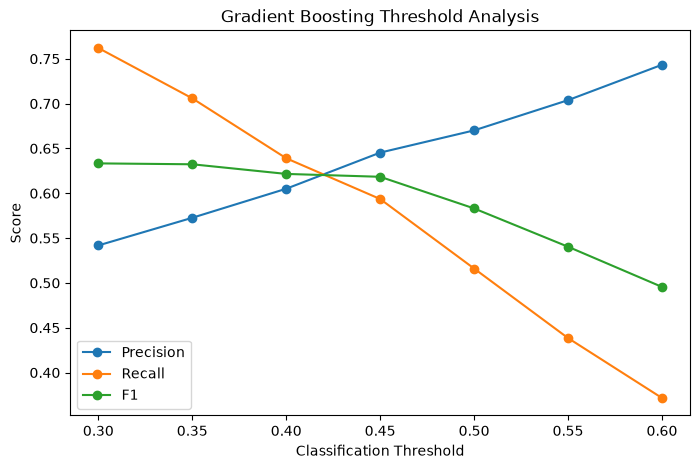

In [68]:
plt.figure(figsize=(8, 5))

plt.plot(
    threshold_df["Threshold"],
    threshold_df["Precision"],
    marker="o",
    label="Precision"
)

plt.plot(
    threshold_df["Threshold"],
    threshold_df["Recall"],
    marker="o",
    label="Recall"
)

plt.plot(
    threshold_df["Threshold"],
    threshold_df["F1"],
    marker="o",
    label="F1"
)

plt.xlabel("Classification Threshold")
plt.ylabel("Score")
plt.title("Gradient Boosting Threshold Analysis")
plt.legend()

plt.show()

In [69]:
best_threshold_row = threshold_df.loc[
    threshold_df["F1"].idxmax()
]

best_threshold_row

Threshold    0.300000
Precision    0.541825
Recall       0.762032
F1           0.633333
Name: 0, dtype: float64

In [70]:
pred_50 = (gb_prob >= 0.50).astype(int)
pred_40 = (gb_prob >= 0.40).astype(int)

In [71]:
comparison = pd.DataFrame([
    {
        "Threshold": 0.50,
        "Precision": precision_score(y_test, pred_50),
        "Recall": recall_score(y_test, pred_50),
        "F1": f1_score(y_test, pred_50)
    },
    {
        "Threshold": 0.40,
        "Precision": precision_score(y_test, pred_40),
        "Recall": recall_score(y_test, pred_40),
        "F1": f1_score(y_test, pred_40)
    }
])

comparison

,Threshold,Precision,Recall,F1
0,0.5,0.670139,0.516043,0.583082
1,0.4,0.605063,0.639037,0.621586


## Model Interpretation

Predictive performance tells us whether a model works, but it does not explain why customers receive high churn predictions.

To understand the model better, feature importance from the tuned Gradient Boosting model and coefficients from Balanced Logistic Regression are analyzed.

These values represent associations learned by the models and should not be interpreted as causal effects.

In [72]:
gb_preprocessor = gb_model.named_steps["preprocessor"]
gb_classifier = gb_model.named_steps["model"]

In [73]:
feature_names = gb_preprocessor.get_feature_names_out()

len(feature_names)

52

In [74]:
gb_importance = pd.DataFrame({
    "Feature": feature_names,
    "Importance": gb_classifier.feature_importances_
})

In [75]:
gb_importance["Feature"] = (
    gb_importance["Feature"]
    .str.replace("num__", "", regex=False)
    .str.replace("cat__", "", regex=False)
)

In [76]:
gb_importance = gb_importance.sort_values(
    "Importance",
    ascending=False
).reset_index(drop=True)

gb_importance.head(15)

,Feature,Importance
0,Contract_Month-to-month,0.371768
1,tenure,0.148793
2,InternetService_Fiber optic,0.094105
3,TotalCharges,0.077156
4,OnlineSecurity_No,0.069939
5,MonthlyCharges,0.067698
6,TechSupport_No,0.048521
7,PaymentMethod_Electronic check,0.041130
8,MultipleLines_No,0.013013
9,PaperlessBilling_Yes,0.011523


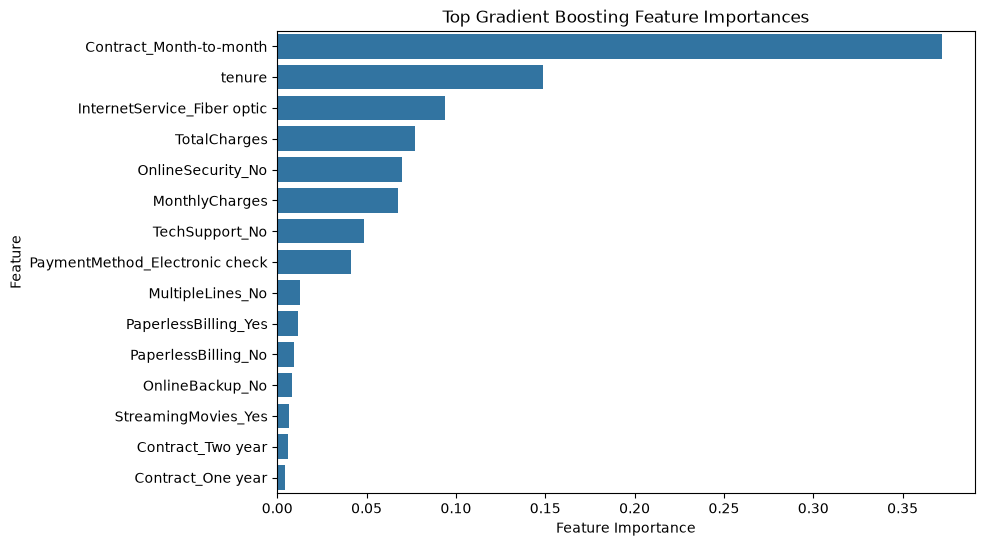

In [77]:
top_gb_features = gb_importance.head(15)

plt.figure(figsize=(9, 6))

sns.barplot(
    data=top_gb_features,
    x="Importance",
    y="Feature"
)

plt.title("Top Gradient Boosting Feature Importances")
plt.xlabel("Feature Importance")
plt.ylabel("Feature")

plt.show()

In [78]:
log_preprocessor = log_model.named_steps["preprocessor"]
log_classifier = log_model.named_steps["model"]

In [79]:
log_feature_names = log_preprocessor.get_feature_names_out()

In [80]:
coefficients = log_classifier.coef_[0]

In [81]:
log_coefficients = pd.DataFrame({
    "Feature": log_feature_names,
    "Coefficient": coefficients
})

In [82]:
log_coefficients["Feature"] = (
    log_coefficients["Feature"]
    .str.replace("num__", "", regex=False)
    .str.replace("cat__", "", regex=False)
)

In [83]:
log_coefficients.sort_values(
    "Coefficient",
    ascending=False
).head(15)

,Feature,Coefficient
18,InternetService_Fiber optic,0.747084
38,Contract_Month-to-month,0.718655
51,TenureGroup_61+ months,0.367123
3,TotalServices,0.337735
50,TenureGroup_49-60 months,0.264464
20,OnlineSecurity_No,0.246151
45,PaymentMethod_Electronic check,0.244073
37,StreamingMovies_Yes,0.221758
34,StreamingTV_Yes,0.210260
29,TechSupport_No,0.209839


In [84]:
log_coefficients.sort_values(
    "Coefficient",
    ascending=True
).head(15)

,Feature,Coefficient
0,tenure,-1.053480
40,Contract_Two year,-0.844529
1,MonthlyCharges,-0.690024
17,InternetService_DSL,-0.672222
48,TenureGroup_13-24 months,-0.465779
41,PaperlessBilling_No,-0.248698
49,TenureGroup_25-48 months,-0.231820
30,TechSupport_No internet service,-0.225445
24,OnlineBackup_No internet service,-0.225445
21,OnlineSecurity_No internet service,-0.225445


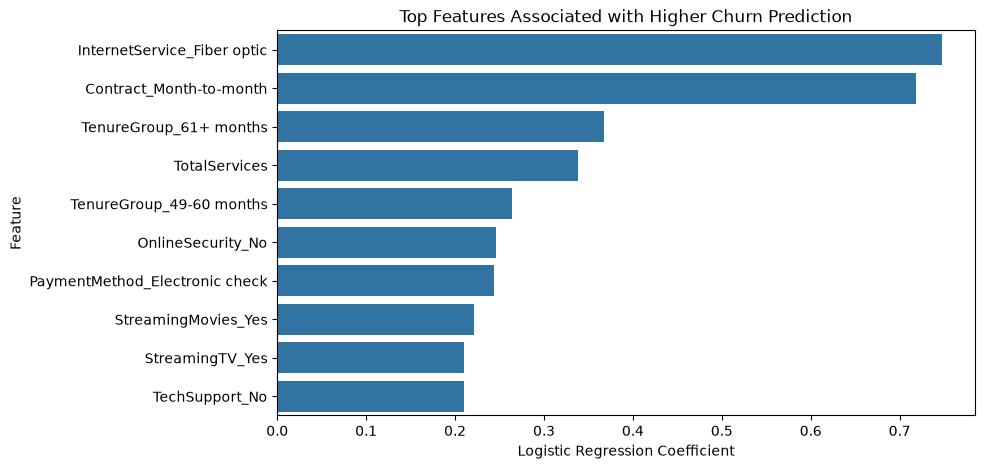

In [85]:
positive_features = (
    log_coefficients
    .sort_values("Coefficient", ascending=False)
    .head(10)
)

plt.figure(figsize=(9, 5))

sns.barplot(
    data=positive_features,
    x="Coefficient",
    y="Feature"
)

plt.title("Top Features Associated with Higher Churn Prediction")
plt.xlabel("Logistic Regression Coefficient")
plt.ylabel("Feature")

plt.show()

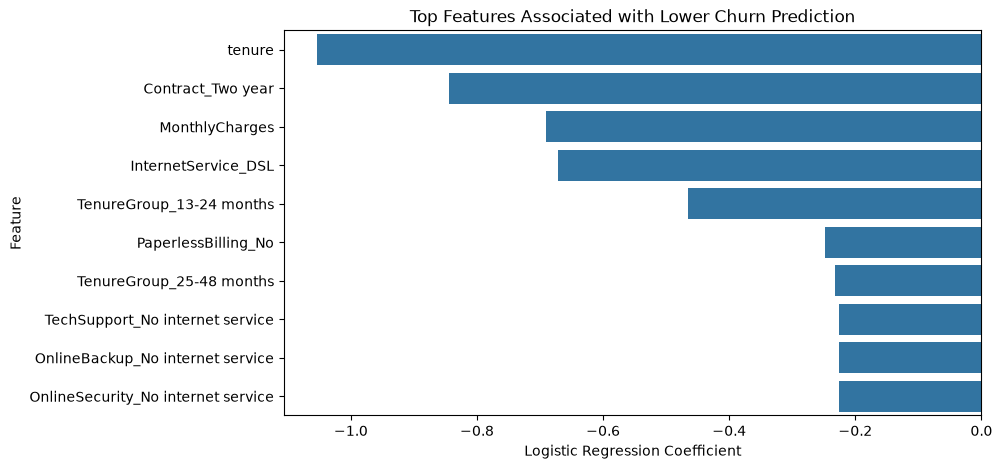

In [86]:
negative_features = (
    log_coefficients
    .sort_values("Coefficient")
    .head(10)
)

plt.figure(figsize=(9, 5))

sns.barplot(
    data=negative_features,
    x="Coefficient",
    y="Feature"
)

plt.title("Top Features Associated with Lower Churn Prediction")
plt.xlabel("Logistic Regression Coefficient")
plt.ylabel("Feature")

plt.show()

### Interpreting Model Features

Gradient Boosting feature importance indicates which variables were useful for prediction but does not directly indicate whether they increase or decrease churn risk.

Logistic Regression coefficients provide directional information:

- Positive coefficients are associated with higher predicted churn risk.
- Negative coefficients are associated with lower predicted churn risk.

Because categorical variables are one-hot encoded and several customer characteristics are correlated, individual coefficients should be interpreted as model associations rather than causal effects.

In [87]:
gb_importance.head(15)

,Feature,Importance
0,Contract_Month-to-month,0.371768
1,tenure,0.148793
2,InternetService_Fiber optic,0.094105
3,TotalCharges,0.077156
4,OnlineSecurity_No,0.069939
5,MonthlyCharges,0.067698
6,TechSupport_No,0.048521
7,PaymentMethod_Electronic check,0.041130
8,MultipleLines_No,0.013013
9,PaperlessBilling_Yes,0.011523


In [88]:
log_coefficients.sort_values(
    "Coefficient",
    ascending=False
).head(10)

,Feature,Coefficient
18,InternetService_Fiber optic,0.747084
38,Contract_Month-to-month,0.718655
51,TenureGroup_61+ months,0.367123
3,TotalServices,0.337735
50,TenureGroup_49-60 months,0.264464
20,OnlineSecurity_No,0.246151
45,PaymentMethod_Electronic check,0.244073
37,StreamingMovies_Yes,0.221758
34,StreamingTV_Yes,0.210260
29,TechSupport_No,0.209839


In [89]:
log_coefficients.sort_values(
    "Coefficient"
).head(10)

,Feature,Coefficient
0,tenure,-1.053480
40,Contract_Two year,-0.844529
1,MonthlyCharges,-0.690024
17,InternetService_DSL,-0.672222
48,TenureGroup_13-24 months,-0.465779
41,PaperlessBilling_No,-0.248698
49,TenureGroup_25-48 months,-0.231820
30,TechSupport_No internet service,-0.225445
24,OnlineBackup_No internet service,-0.225445
21,OnlineSecurity_No internet service,-0.225445


### Gradient Boosting Interpretation

The tuned Gradient Boosting model identifies several of the same factors highlighted during exploratory analysis.

The most important predictive features include:

- Month-to-month contracts
- Customer tenure
- Fiber optic internet service
- Total charges
- Lack of Online Security
- Monthly charges
- Lack of Tech Support
- Electronic check payment

The agreement between exploratory analysis and model importance increases confidence that these variables contain meaningful information for churn prediction.

Feature importance indicates how useful a feature was for prediction, but it does not prove that the feature causes churn.

### Interpretable Logistic Regression

The predictive Logistic Regression model contains some correlated and derived features such as both `tenure` and `TenureGroup`, and both individual service indicators and `TotalServices`.

These features can make individual Logistic Regression coefficients difficult to interpret.

Therefore, a simplified Logistic Regression model is created for interpretation using the original features without the redundant engineered variables.

In [90]:
from sklearn.pipeline import Pipeline
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.compose import ColumnTransformer
from sklearn.linear_model import LogisticRegression

In [91]:
X_interpret = X.drop(
    columns=[
        "TenureGroup",
        "TotalServices"
    ]
)

In [92]:
interpret_num = [
    "tenure",
    "MonthlyCharges",
    "TotalCharges"
]

In [93]:
interpret_cat = [
    col for col in X_interpret.columns
    if col not in interpret_num
]

In [94]:
interpret_num_pipeline = Pipeline(
    steps=[
        ("imputer", SimpleImputer(strategy="median")),
        ("scaler", StandardScaler())
    ]
)

In [95]:
interpret_cat_pipeline = Pipeline(
    steps=[
        ("imputer", SimpleImputer(strategy="most_frequent")),
        ("encoder", OneHotEncoder(
            handle_unknown="ignore",
            drop="first"
        ))
    ]
)

In [96]:
interpret_preprocessor = ColumnTransformer(
    transformers=[
        ("num", interpret_num_pipeline, interpret_num),
        ("cat", interpret_cat_pipeline, interpret_cat)
    ]
)

In [97]:
X_int_train, X_int_test, y_int_train, y_int_test = train_test_split(
    X_interpret,
    y,
    test_size=0.20,
    random_state=42,
    stratify=y
)

In [98]:
interpret_log_model = Pipeline(
    steps=[
        ("preprocessor", interpret_preprocessor),
        ("model", LogisticRegression(
            class_weight="balanced",
            max_iter=1000,
            random_state=42
        ))
    ]
)

interpret_log_model.fit(
    X_int_train,
    y_int_train
)

,"steps steps: list of tuplesList of (name of step, estimator) tuples that are to be chained insequential order. To be compatible with the scikit-learn API, all stepsmust define `fit`. All non-last steps must also define `transform`. See:ref:`Combining Estimators <combining_estimators>` for more details.","[('preprocessor', ...), ('model', ...)]"
,"transform_input transform_input: list of str, default=NoneThe names of the :term:`metadata` parameters that should be transformed by thepipeline before passing it to the step consuming it.This enables transforming some input arguments to ``fit`` (other than ``X``)to be transformed by the steps of the pipeline up to the step which requiresthem. Requirement is defined via :ref:`metadata routing <metadata_routing>`.For instance, this can be used to pass a validation set through the pipeline.You can only set this if metadata routing is enabled, which youcan enable using ``sklearn.set_config(enable_metadata_routing=True)``... versionadded:: 1.6",None
,"memory memory: str or object with the joblib.Memory interface, default=NoneUsed to cache the fitted transformers of the pipeline. The last stepwill never be cached, even if it is a transformer. By default, nocaching is performed. If a string is given, it is the path to thecaching directory. Enabling caching triggers a clone of the transformersbefore fitting. Therefore, the transformer instance given to thepipeline cannot be inspected directly. Use the attribute ``named_steps``or ``steps`` to inspect estimators within the pipeline. Caching thetransformers is advantageous when fitting is time consuming. See:ref:`sphx_glr_auto_examples_neighbors_plot_caching_nearest_neighbors.py`for an example on how to enable caching.",None
,"verbose verbose: bool, default=FalseIf True, the time elapsed while fitting each step will be printed as itis completed.",False
Name,Type,Value
"classes_ classes_: ndarray of shape (n_classes,)The classes labels. Only exist if the last step of the pipeline is aclassifier.","ndarray[int64](2,)","[0,1]"
"feature_names_in_ feature_names_in_: ndarray of shape (`n_features_in_`,)Names of features seen during :term:`fit`. Only defined if theunderlying estimator exposes such an attribute when fit... versionadded:: 1.0","ndarray[object](19,)","['gender','SeniorCitizen','Partner',...,'PaymentMethod','MonthlyCharges', 'TotalCharges']"
n_features_in_ n_features_in_: intNumber of features seen during :term:`fit`. Only defined if theunderlying first estimator in `steps` exposes such an attributewhen fit... versionadded:: 0.24,int,19
,"transformers transformers: list of tuplesList of (name, transformer, columns) tuples specifying thetransformer objects to be applied to subsets of the data.name : str Like in Pipeline and FeatureUnion, this allows the transformer and its parameters to be set using ``set_params`` and searched in grid search.transformer : {'drop', 'passthrough'} or estimator Estimator must support :term:`fit` and :term:`transform`. Special-cased strings 'drop' and 'passthrough' are accepted as well, to indicate to drop the columns or to pass them through untransformed, respectively.columns : str, array-like of str, int, array-like of int, array-like of bool, slice or callable Indexes the data on its second axis. Integers are interpreted as positional columns, while strings can reference DataFrame columns by name. A scalar string or int should be used where ``transformer`` expects X to be a 1d array-like (vector), otherwise a 2d array will be passed to the transformer. A callable is passed the input data `X` and can return any of the above. To select multiple columns by name or dtype, you can use :obj:`make_column_selector`.","[('num', ...), ('cat', ...)]"
,"remainder remainder: {'drop', 'passthrough'} or estimator, default='drop'By default, only the specified columns in `transformers` aretransformed and combined in the output, and the non-specifiedcolumns are dropped. (default of ``'drop'``).By specifying ``remainder='pa

### Coefficients from the simplified model

Positive coefficient = associated with higher predicted churn; negative coefficient
= associated with lower predicted churn, holding the other encoded inputs fixed.
Numerical coefficients refer to a one-standard-deviation increase. Categorical
coefficients are relative to the omitted category shown below. These are log-odds
coefficients, not probability changes or causal effects. Removing the engineered
duplicates helps interpretation, but tenure, charges and service choices remain
correlated. Coefficient magnitudes across different encodings are not directly comparable.

,Feature,Reference category
0,gender,Female
1,SeniorCitizen,0
2,Partner,No
3,Dependents,No
4,PhoneService,No
5,MultipleLines,No
6,InternetService,DSL
7,OnlineSecurity,No
8,OnlineBackup,No
9,DeviceProtection,No


,Feature,Coefficient
0,InternetService_Fiber optic,1.2224
1,TotalCharges,0.4865
2,StreamingMovies_Yes,0.4206
3,PaymentMethod_Electronic check,0.4025
4,StreamingTV_Yes,0.3954
5,PaperlessBilling_Yes,0.3364
6,MultipleLines_Yes,0.3247
7,SeniorCitizen_1,0.1539
8,PaymentMethod_Mailed check,0.0523
9,DeviceProtection_Yes,0.0412


,Feature,Coefficient
29,Contract_Two year,-1.4125
28,tenure,-1.1562
27,Contract_One year,-0.7153
26,MonthlyCharges,-0.5462
25,PhoneService_Yes,-0.3480
24,OnlineSecurity_Yes,-0.3349
23,TechSupport_Yes,-0.2686
22,Dependents_Yes,-0.2312
21,MultipleLines_No phone service,-0.1893
17,DeviceProtection_No internet service,-0.1830


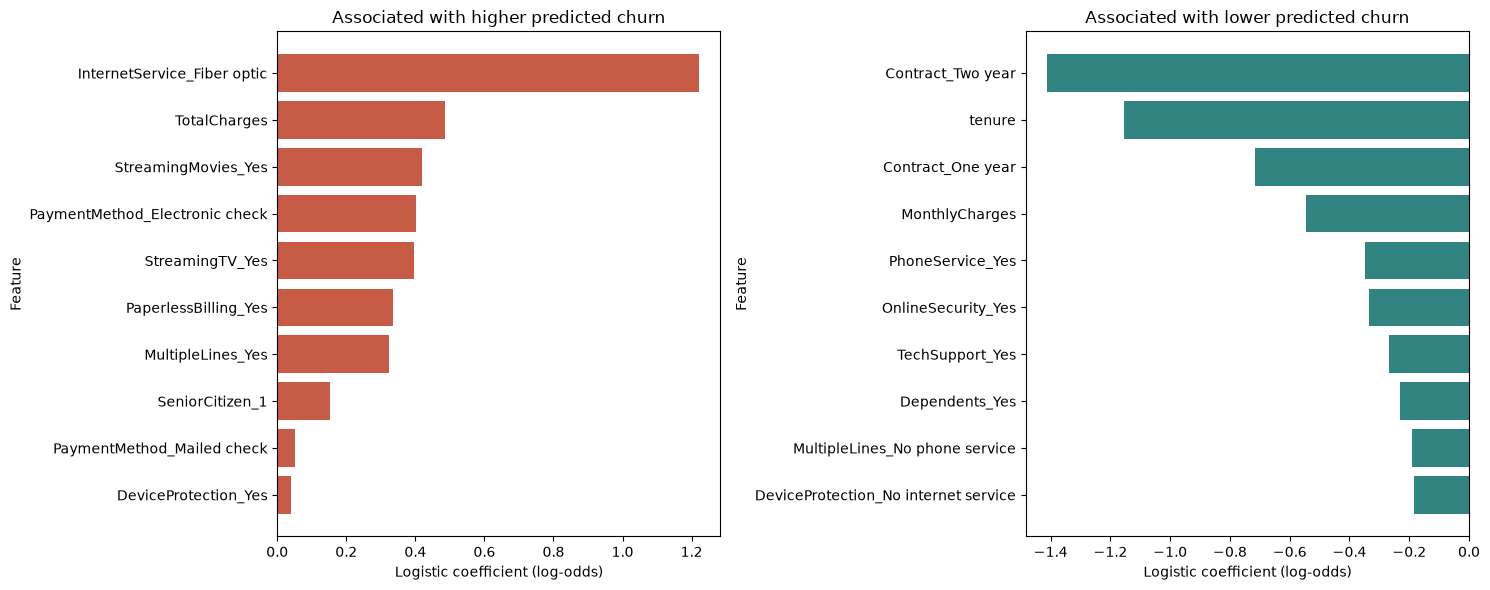

In [99]:
int_preprocessor = interpret_log_model.named_steps['preprocessor']
interpret_coefficients = pd.DataFrame({
    'Feature': [name.split('__', 1)[-1] for name in int_preprocessor.get_feature_names_out()],
    'Coefficient': interpret_log_model.named_steps['model'].coef_[0],
}).sort_values('Coefficient', ascending=False).reset_index(drop=True)
encoder = int_preprocessor.named_transformers_['cat'].named_steps['encoder']
reference_categories = pd.DataFrame({
    'Feature': interpret_cat,
    'Reference category': [categories[index] for categories, index
                           in zip(encoder.categories_, encoder.drop_idx_)],
})
display(reference_categories)
positive = interpret_coefficients.query('Coefficient > 0').head(10)
negative = interpret_coefficients.query('Coefficient < 0').sort_values('Coefficient').head(10)
display(positive.style.format({'Coefficient': '{:.4f}'}))
display(negative.style.format({'Coefficient': '{:.4f}'}))
fig, axes = plt.subplots(1, 2, figsize=(15, 6))
for ax, table, title, color in zip(axes, [positive, negative],
        ['Associated with higher predicted churn', 'Associated with lower predicted churn'],
        ['#c65b46', '#328482']):
    ax.barh(table['Feature'], table['Coefficient'], color=color)
    ax.invert_yaxis()
    ax.set(title=title, xlabel='Logistic coefficient (log-odds)', ylabel='Feature')
    ax.axvline(0, color='gray', linewidth=0.7)
fig.tight_layout()
(ROOT / 'images').mkdir(exist_ok=True)
fig.savefig(ROOT / 'images/interpretable_coefficients.png', dpi=150, bbox_inches='tight')
plt.show()

## Key Churn Drivers

The table combines full-sample descriptive EDA, Gradient Boosting importance and training-fitted simplified Logistic Regression coefficients. Importance has no direction; EDA and coefficients describe different, potentially conflicting associations.

In [100]:
coef = interpret_coefficients.set_index('Feature')['Coefficient']
importance = gb_importance.set_index('Feature')['Importance']
driver_rows = []
for column, category, coefficient_feature, comparison_text in [
    ('Contract', 'Month-to-month', 'Contract_Two year', 'Two year vs Month-to-month'),
    ('InternetService', 'Fiber optic', 'InternetService_Fiber optic', 'Fiber optic vs DSL'),
    ('OnlineSecurity', 'No', 'OnlineSecurity_Yes', 'Yes vs No'),
    ('TechSupport', 'No', 'TechSupport_Yes', 'Yes vs No'),
    ('PaymentMethod', 'Electronic check', 'PaymentMethod_Electronic check', 'Electronic check vs Bank transfer (automatic)'),
]:
    selected = df[column].eq(category)
    driver_rows.append({
        'Factor': f'{column}: {category}',
        'EDA evidence': f'Churn {df.loc[selected, "ChurnFlag"].mean():.1%}; other categories {df.loc[~selected, "ChurnFlag"].mean():.1%}',
        'GB importance': float(importance.get(f'{column}_{category}', 0)),
        'Logistic comparison': comparison_text,
        'Coefficient': float(coef[coefficient_feature]),
    })
for column in ['tenure', 'MonthlyCharges']:
    means = df.groupby('ChurnFlag')[column].mean()
    driver_rows.append({
        'Factor': column,
        'EDA evidence': f'Mean churned {means[1]:.2f}; retained {means[0]:.2f}',
        'GB importance': float(importance[column]),
        'Logistic comparison': 'One standard deviation increase',
        'Coefficient': float(coef[column]),
    })
drivers = pd.DataFrame(driver_rows)
display(drivers.style.format({'GB importance': '{:.4f}', 'Coefficient': '{:.4f}'}))
eda_rates = pd.concat([
    df.groupby(column)['ChurnFlag'].agg(Customers='size', ChurnRate='mean')
      .reset_index().rename(columns={column: 'Category'}).assign(Feature=column)
    for column in ['Contract', 'InternetService', 'PaymentMethod', 'OnlineSecurity', 'TechSupport']
], ignore_index=True)
display(eda_rates)
display(Markdown(
    'Month-to-month contracts, fiber optic service, electronic checks and missing security/support '
    'have higher observed churn than their comparison groups. Longer contracts and customers with '
    'security/support show lower observed churn. Churned customers have shorter average tenure and '
    'higher average monthly charges. These patterns are also represented among the Gradient Boosting '
    'features. Read the coefficient column with its reference category: the monthly-charge coefficient '
    f'is {coef["MonthlyCharges"]:.4f}, so its adjusted direction need not match the unadjusted EDA. '
    'Correlated charges and bundled services prevent a simple causal interpretation.'
))

,Factor,EDA evidence,GB importance,Logistic comparison,Coefficient
0,Contract: Month-to-month,Churn 42.7%; other categories 6.8%,0.3718,Two year vs Month-to-month,-1.4125
1,InternetService: Fiber optic,Churn 41.9%; other categories 14.5%,0.0941,Fiber optic vs DSL,1.2224
2,OnlineSecurity: No,Churn 41.8%; other categories 11.5%,0.0699,Yes vs No,-0.3349
3,TechSupport: No,Churn 41.6%; other categories 11.8%,0.0485,Yes vs No,-0.2686
4,PaymentMethod: Electronic check,Churn 45.3%; other categories 17.1%,0.0411,Electronic check vs Bank transfer (automatic),0.4025
5,tenure,Mean churned 17.98; retained 37.57,0.1488,One standard deviation increase,-1.1562
6,MonthlyCharges,Mean churned 74.44; retained 61.27,0.0677,One standard deviation increase,-0.5462


,Category,Customers,ChurnRate,Feature
0,Month-to-month,3875,0.427097,Contract
1,One year,1473,0.112695,Contract
2,Two year,1695,0.028319,Contract
3,DSL,2421,0.189591,InternetService
4,Fiber optic,3096,0.418928,InternetService
5,No,1526,0.074050,InternetService
6,Bank transfer (automatic),1544,0.167098,PaymentMethod
7,Credit card (automatic),1522,0.152431,PaymentMethod
8,Electronic check,2365,0.452854,PaymentMethod
9,Mailed check,1612,0.191067,PaymentMethod


Month-to-month contracts, fiber optic service, electronic checks and missing security/support have higher observed churn than their comparison groups. Longer contracts and customers with security/support show lower observed churn. Churned customers have shorter average tenure and higher average monthly charges. These patterns are also represented among the Gradient Boosting features. Read the coefficient column with its reference category: the monthly-charge coefficient is -0.5462, so its adjusted direction need not match the unadjusted EDA. Correlated charges and bundled services prevent a simple causal interpretation.

## Customer Risk Segmentation

Use tuned Gradient Boosting scores for the held-out test customers only. Training
customers are excluded from these summaries. Actual labels are joined after prediction.

- Low Risk: probability < 0.30
- Medium Risk: 0.30 <= probability < 0.60
- High Risk: probability >= 0.60

These are demonstration thresholds, not calibrated business guarantees. A real business
should consider retention budget, false-positive and false-negative costs, and customer
lifetime value, using validation data. Probability calibration has not been established.

,Customers,ChurnRate,Percentage
RiskCategory,,,
Low Risk,883,10.1%,62.7%
Medium Risk,339,43.1%,24.1%
High Risk,187,74.3%,13.3%


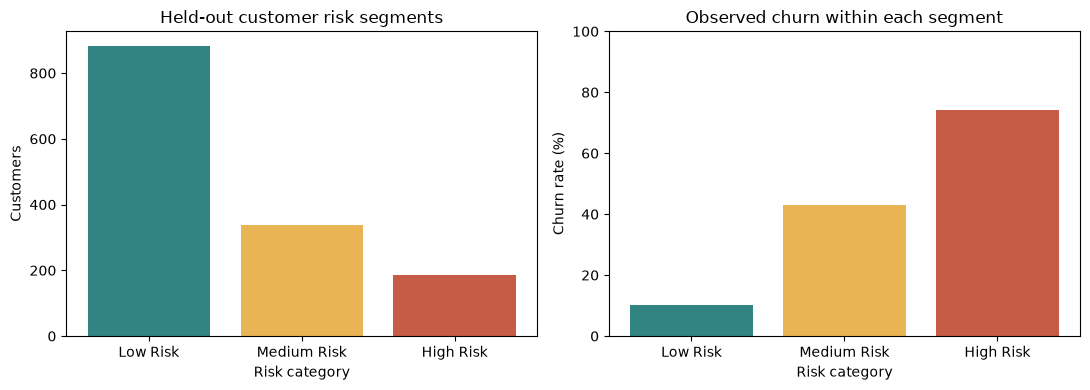

In [101]:
risk_customers = df.loc[X_test.index, ['customerID']].copy()
risk_customers['ActualChurn'] = y_test
risk_customers['ChurnProbability'] = gb_prob
risk_customers['RiskCategory'] = risk_categories(gb_prob)
risk_summary = risk_customers.groupby('RiskCategory', observed=False).agg(
    Customers=('customerID', 'size'), ChurnRate=('ActualChurn', 'mean')
)
risk_summary['Percentage'] = 100 * risk_summary['Customers'] / len(risk_customers)
display(risk_summary.style.format({'ChurnRate': '{:.1%}', 'Percentage': '{:.1f}%'}))
fig, axes = plt.subplots(1, 2, figsize=(11, 4))
colors = ['#328482', '#e8b454', '#c65b46']
axes[0].bar(risk_summary.index.astype(str), risk_summary['Customers'], color=colors)
axes[0].set(title='Held-out customer risk segments', xlabel='Risk category', ylabel='Customers')
axes[1].bar(risk_summary.index.astype(str), 100 * risk_summary['ChurnRate'], color=colors)
axes[1].set(title='Observed churn within each segment', xlabel='Risk category', ylabel='Churn rate (%)', ylim=(0, 100))
fig.tight_layout()
fig.savefig(ROOT / 'images/risk_segments.png', dpi=150, bbox_inches='tight')
plt.show()

## High-Risk Customer Prioritization

This historical held-out sample demonstrates a retention queue, not a list of active
customers to contact. Actual churn is excluded from the priority table and model inputs.
Scores are sorted from highest to lowest; capacity and customer value would guide a real campaign.

In [102]:
priority_columns = ['tenure', 'Contract', 'InternetService', 'MonthlyCharges',
                    'TechSupport', 'OnlineSecurity', 'PaymentMethod']
high_risk_customers = (
    risk_customers.loc[risk_customers['RiskCategory'].eq('High Risk'),
                       ['customerID', 'ChurnProbability', 'RiskCategory']]
    .join(df[priority_columns])
    .sort_values('ChurnProbability', ascending=False)
)
display(high_risk_customers.head(20).style.format({'ChurnProbability': '{:.1%}', 'MonthlyCharges': '{:.2f}'}))

,customerID,ChurnProbability,RiskCategory,tenure,Contract,InternetService,MonthlyCharges,TechSupport,OnlineSecurity,PaymentMethod
3380,5178-LMXOP,90.1%,High Risk,1,Month-to-month,Fiber optic,95.10,No,No,Electronic check
6866,0295-PPHDO,89.7%,High Risk,1,Month-to-month,Fiber optic,95.45,No,No,Electronic check
4585,1069-XAIEM,88.8%,High Risk,1,Month-to-month,Fiber optic,85.05,No,No,Electronic check
6623,9248-OJYKK,88.0%,High Risk,1,Month-to-month,Fiber optic,76.45,No,No,Electronic check
2631,6861-XWTWQ,87.0%,High Risk,7,Month-to-month,Fiber optic,99.25,No,No,Electronic check
2464,2609-IAICY,86.8%,High Risk,1,Month-to-month,Fiber optic,77.15,No,No,Electronic check
2797,6023-YEBUP,86.6%,High Risk,3,Month-to-month,Fiber optic,100.95,No,No,Electronic check
383,5167-ZFFMM,86.4%,High Risk,1,Month-to-month,Fiber optic,90.85,No,No,Credit card (automatic)
6365,8884-ADFVN,86.3%,High Risk,7,Month-to-month,Fiber optic,101.95,No,No,Electronic check
3727,9057-SIHCH,85.5%,High Risk,3,Month-to-month,Fiber optic,96.60,No,No,Electronic check


## Business Recommendations

- Test optional longer-contract incentives for month-to-month customers, whose observed churn is higher.
- Test onboarding check-ins for newer customers; churned customers have shorter tenure on average.
- Investigate fiber optic customer experience and perceived value before changing pricing.
- Review plan fit for customers with high monthly charges. EDA supports investigation, while correlated model inputs make the adjusted effect uncertain.
- Test useful Tech Support and Online Security offers where appropriate; these services are associated with lower observed churn, not proven protection against churn.
- Investigate payment friction among electronic-check users, with optional simpler payment methods.
- Use the high-risk queue to allocate a limited pilot retention budget, with randomized control groups and measured incremental retention and cost.

These are actions worth testing. The observational dataset does not establish that any intervention reduces churn.

## Final Model Decision

Compare both predictive models at the unchanged 0.50 class threshold. The simplified
Logistic Regression serves interpretation only. No model is universally best; ROC-AUC
measures ranking, while precision and recall depend on the chosen threshold.

,Model,Accuracy,Precision,Recall,F1,ROC-AUC
0,Tuned Gradient Boosting,0.8041,0.6701,0.5160,0.5831,0.8472
1,Balanced Logistic Regression,0.7331,0.4983,0.7914,0.6116,0.8422
2,Interpretable Logistic Regression,0.7381,0.5043,0.7834,0.6136,0.8417


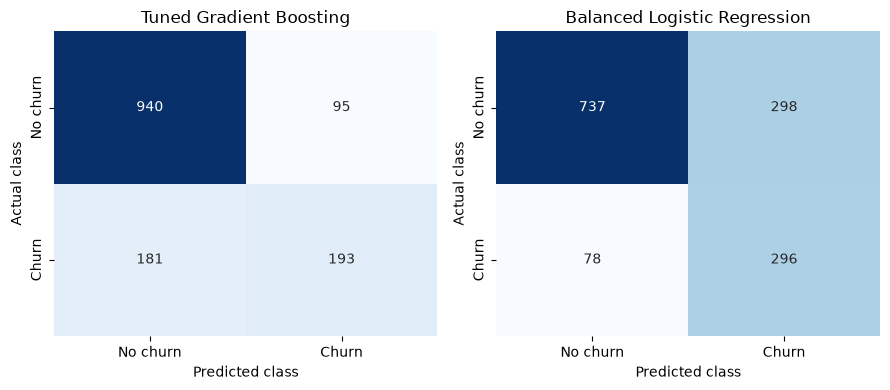

Use **tuned Gradient Boosting for general risk ranking** (test ROC-AUC 0.8472). At 0.50 it has precision 67.0% and recall 51.6%. Use **balanced Logistic Regression when recall is the priority**: recall 79.1%, with precision 49.8% and more false positives. Gradient Boosting has higher accuracy and precision here, while balanced Logistic Regression has higher F1. Its AUC advantage is small and has no reported uncertainty interval. A lower Gradient Boosting threshold is another candidate to validate when missing churners is expensive.

In [103]:
evaluation_rows = []
for name, model, features in [
    ('Tuned Gradient Boosting', gb_model, X_test),
    ('Balanced Logistic Regression', log_model, X_test),
    ('Interpretable Logistic Regression', interpret_log_model, X_int_test),
]:
    probability = model.predict_proba(features)[:, 1]
    prediction = (probability >= 0.50).astype(int)
    evaluation_rows.append({
        'Model': name, 'Accuracy': accuracy_score(y_test, prediction),
        'Precision': precision_score(y_test, prediction, zero_division=0),
        'Recall': recall_score(y_test, prediction, zero_division=0),
        'F1': f1_score(y_test, prediction, zero_division=0),
        'ROC-AUC': roc_auc_score(y_test, probability),
    })
evaluation = pd.DataFrame(evaluation_rows)
display(evaluation.style.format({col: '{:.4f}' for col in evaluation.columns if col != 'Model'}))
fig, axes = plt.subplots(1, 2, figsize=(9, 4))
for ax, name, probabilities in zip(axes, ['Tuned Gradient Boosting', 'Balanced Logistic Regression'], [gb_prob, log_prob]):
    sns.heatmap(confusion_matrix(y_test, probabilities >= 0.5), annot=True, fmt='d',
                cmap='Blues', cbar=False, ax=ax,
                xticklabels=['No churn', 'Churn'], yticklabels=['No churn', 'Churn'])
    ax.set(title=name, xlabel='Predicted class', ylabel='Actual class')
fig.tight_layout()
plt.show()
display(Markdown(
    f'Use **tuned Gradient Boosting for general risk ranking** (test ROC-AUC {gb_auc:.4f}). '
    f'At 0.50 it has precision {evaluation.iloc[0]["Precision"]:.1%} and recall {evaluation.iloc[0]["Recall"]:.1%}. '
    f'Use **balanced Logistic Regression when recall is the priority**: recall {evaluation.iloc[1]["Recall"]:.1%}, '
    f'with precision {evaluation.iloc[1]["Precision"]:.1%} and more false positives. '
    'Gradient Boosting has higher accuracy and precision here, while balanced Logistic Regression has higher F1. '
    'Its AUC advantage is small and has no reported uncertainty interval. A lower Gradient Boosting threshold '
    'is another candidate to validate when missing churners is expensive.'
))

## Save Final Artifacts

Preserve the existing fitted estimators and preprocessing. Add deterministic feature
derivation to each predictive pipeline so it accepts the original 19 raw features.
No model is refitted on test data. The interpretation pipeline uses those original
features directly. The app and external Python callers must run with this repository
on their Python import path because the feature function lives in `src.churn`.

Exports below record held-out metrics and customer IDs, dataset hashes, package versions
and input schema. Re-running this notebook safely refreshes the artifacts.

In [104]:
import hashlib

pd.testing.assert_frame_equal(add_features(df), X, check_dtype=False)
for filename, fitted_model, expected in [
    ('tuned_gradient_boosting.joblib', gb_model, gb_prob),
    ('balanced_logistic_regression.joblib', log_model, log_prob),
]:
    if 'features' not in fitted_model.named_steps:
        feature_step = FunctionTransformer(add_features).fit(X_train[RAW_FEATURES])
        fitted_model = Pipeline([('features', feature_step), *fitted_model.steps])
    np.testing.assert_allclose(fitted_model.predict_proba(X_test[RAW_FEATURES])[:, 1], expected)
    joblib.dump(fitted_model, ROOT / 'models' / filename)
    reloaded = joblib.load(ROOT / 'models' / filename)
    np.testing.assert_allclose(reloaded.predict_proba(X_test[RAW_FEATURES])[:, 1], expected)
joblib.dump(interpret_log_model, ROOT / 'models/interpretable_logistic_regression.joblib')
np.testing.assert_allclose(
    joblib.load(ROOT / 'models/interpretable_logistic_regression.joblib').predict_proba(X_int_test),
    interpret_log_model.predict_proba(X_int_test),
)
for filename, table in [
    ('customer_risk_segments.csv', risk_customers),
    ('risk_summary.csv', risk_summary.reset_index()),
    ('high_risk_customers.csv', high_risk_customers),
    ('model_evaluation.csv', evaluation),
    ('gradient_boosting_importance.csv', gb_importance),
    ('interpretable_logistic_coefficients.csv', interpret_coefficients),
    ('key_churn_drivers.csv', drivers),
    ('eda_churn_rates.csv', eda_rates),
]:
    table.to_csv(ROOT / 'data/processed' / filename, index=False)
metadata = {
    'selected_model': 'Tuned Gradient Boosting', 'evaluation_population': 'held-out test customers',
    'random_state': 42, 'test_size': 0.20, 'test_customers': len(X_test),
    'train_customers': len(X_train), 'total_customers': len(df),
    'overall_churn_rate': float(y.mean()), 'class_threshold': 0.50,
    'risk_thresholds': {'medium': 0.30, 'high': 0.60}, 'raw_features': RAW_FEATURES,
    'versions': {'scikit-learn': sklearn.__version__, 'pandas': pd.__version__,
                 'numpy': np.__version__, 'joblib': joblib.__version__},
    'metrics': evaluation.to_dict(orient='records'),
    'data_sha256': {name: hashlib.sha256((ROOT / name).read_bytes()).hexdigest()
                    for name in ['data/raw/WA_Fn-UseC_-Telco-Customer-Churn.csv',
                                 'data/processed/telco_churn_engineered.csv']},
    'test_customer_ids': risk_customers['customerID'].tolist(),
}
(ROOT / 'models/metadata.json').write_text(json.dumps(metadata, indent=2), encoding='utf-8')
print('Saved and reloaded all three complete pipelines; raw-input scores are unchanged.')

Saved and reloaded all three complete pipelines; raw-input scores are unchanged.


## Limitations and Next Steps

This IBM sample is observational and historical; associations do not establish causes.
Only one random stratified split is evaluated, with no time-based validation or confidence
intervals. The existing modeling notebook compares candidates on this same test set, so
it is not a fresh external holdout for the final selection. New validation data is needed
before deployment. Calibrate probabilities and choose business thresholds using training
folds or separate validation data, then evaluate once on a fresh holdout. Check drift,
subgroup performance and intervention lift before operational use. SHAP is deliberately
skipped: feature importance and the simplified coefficient analysis meet this project's scope.